# Fraud Detection with Imbalanced Data 

*This notebook demonstrates how to handle imbalanced data in a fraud detection use case. I compare different oversampling methods and evaluate their impact on model performance. The goal is to show practical solutions for a common real-world challenge in machine learning.*

---

### This is a public dataset from kaggle.com to demonstrate my work.

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler, BorderlineSMOTE

import warnings
warnings.filterwarnings('ignore')

## 1. Introduction  
In real-world applications such as fraud detection, medical diagnosis or anomaly detection, datasets are often highly imbalanced: one class has far fewer examples than the other.  
This notebook demonstrates different **oversampling methods** (SMOTE, ADASYN, etc.) and their impact on model performance, using the popular **credit card fraud dataset**.

Goals:
- Show how class imbalance affects model training  
- Compare multiple resampling techniques  
- Evaluate models with proper metrics
---

## 2. Dataset Overview  
- Source: Kaggle Credit Card Fraud dataset  
- Samples: ~285,000 transactions  
- Minority class: Fraud (≈ 0.17%)  
- Majority class: Non-fraud  



### Load and prepare dataset

In [29]:
data = pd.read_csv('creditcard.csv')

In [62]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [64]:
X = data.drop(columns=['Class'])
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.8, random_state=42)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((227845, 30), (227845,), (56962, 30), (56962,))

## 3. Exploratory Data Analysis (EDA)  
- Visualize class distribution  
- Basic feature statistics  

In [32]:
data.Class.value_counts(normalize=True)*100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

- Nearly the whole dataset consists of non-fraud examples. Less then one percent is fraud data

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

- All data is from the same datatype and we have no missing data. Very well!

In [65]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


<Axes: xlabel='Time', ylabel='Count'>

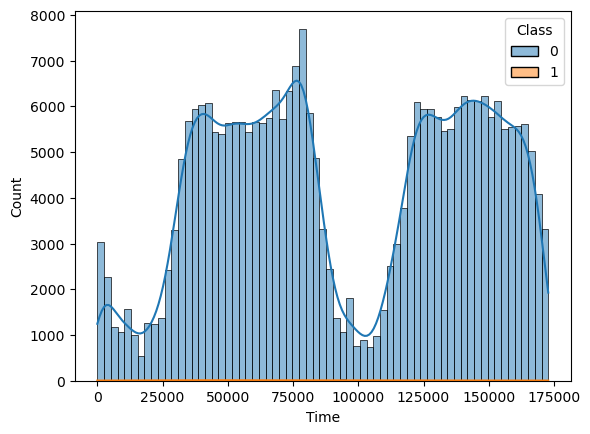

In [34]:
sns.histplot(data=data, x='Time', hue='Class', kde=True)

- Obviously the dataset uses an offsettime. It is not possible to say, on which time the frauds happen...

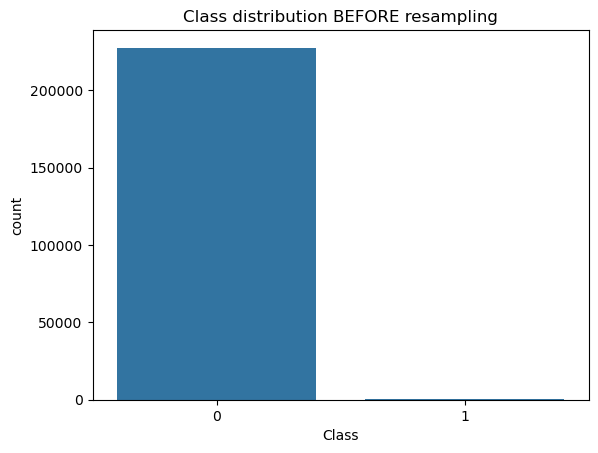

In [68]:
sns.countplot(x=y_train)
plt.title("Class distribution BEFORE resampling");

====================================================================================================

We can clearly see, that the data is very imbalanced. See what happens after the resampling...

====================================================================================================

## 4. Baseline Model (No Resampling)  

- Train a simple model (e.g. Logistic Regression) without resampling  
- Evaluate with **Precision, Recall, F1, ROC-AUC**  

Key Question: *How well does the model perform without resampling?*  

In [192]:
baseline = LogisticRegression()
baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

In [193]:
roc_baseline = roc_auc_score(y_test, y_pred_baseline)
roc_baseline

0.8415729474119418

In [194]:
score_baseline = confusion_matrix(y_test, y_pred_baseline)
score_baseline

array([[56834,    30],
       [   31,    67]])

In [195]:
report_baseline = classification_report(y_test, y_pred_baseline, output_dict=True)

---

## 5. Oversampling Techniques

### 5.1 Random Oversampling (ROS)  
- Duplicates minority class samples  
- Risk: Overfitting

In [196]:
ros = RandomOverSampler(sampling_strategy=0.5, random_state=42)
X_res, y_res = ros.fit_resample(X_train, y_train)

model_ros = LogisticRegression()
model_ros.fit(X_res, y_res)

y_pred_ros = model_ros.predict(X_test)

In [197]:
roc_ros = roc_auc_score(y_test, y_pred_ros)
roc_ros

0.9332996810147806

In [198]:
conf_ros = confusion_matrix(y_test, y_pred_ros)
conf_ros

array([[55661,  1203],
       [   11,    87]])

In [199]:
report_ros = classification_report(y_test, y_pred_ros, output_dict=True)

### 5.2 SMOTE (Synthetic Minority Oversampling Technique)  
- Interpolates new samples between minority neighbors  
- Works well for numeric data

*SMOTE is the big buddy of oversampling methods. It generates new samples from existing samples with slightly other values, but not the same. Lets have a first approach with SMOTE.*

In [109]:
smote = SMOTE(sampling_strategy=0.43, random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

model_smote = LogisticRegression()
model_smote.fit(X_res, y_res)

y_pred_smote = model_smote.predict(X_test)

Text(0.5, 1.0, 'Class distribution AFTER resampling')

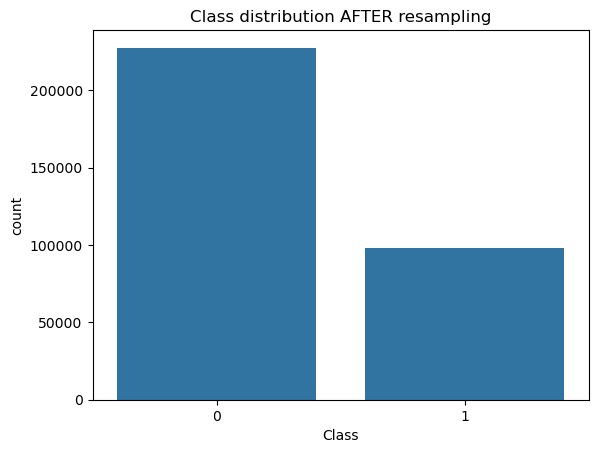

In [60]:
sns.countplot(x=y_res)
plt.title("Class distribution AFTER resampling")

====================================================================================================

Now the data is balanced. To have half as much fraud-samples as non-fraud samples is more than enough.

====================================================================================================

In [110]:
roc_smote = roc_auc_score(y_test, y_pred_smote)
roc_smote

0.9384347401031318

In [111]:
conf_smote = confusion_matrix(y_test, y_pred_smote)
conf_smote

array([[56245,   619],
       [   11,    87]])

In [239]:
report_smote = classification_report(y_test, y_pred_smote, output_dict=True)

### 5.3 ADASYN  
- Focuses on difficult-to-classify regions (decision boundaries)  
- Adaptive oversampling

*The difference between ADASYN and SMOTE is, that ADASYN generates samples from the minority-class also outside the minority and not just between two minorities. It is very efficient but needs some time because it is KNN based, like the most of the oversampling methods.*

In [165]:
ada = ADASYN(sampling_strategy=0.43, n_neighbors=3, random_state=42)
X_res, y_res = ada.fit_resample(X_train, y_train)

model_ada = LogisticRegression()
model_ada.fit(X_res, y_res)

y_pred_ada = model_ada.predict(X_test)

In [166]:
roc_ada = roc_auc_score(y_test, y_pred_ada)
roc_ada

0.9383556039185511

In [167]:
conf_ada = confusion_matrix(y_test, y_pred_ada)
conf_ada

array([[56236,   628],
       [   11,    87]])

In [184]:
report_ada = classification_report(y_test, y_pred_ada, output_dict=True)

### 5.4 Borderline-SMOTE (optional)  
- Generates samples only near the class boundaries

In [152]:
borderline = BorderlineSMOTE(sampling_strategy=0.43, k_neighbors=7, m_neighbors=10,random_state=42)
X_res, y_res = borderline.fit_resample(X_train, y_train)

model_borderline = LogisticRegression()
model_borderline.fit(X_res, y_res)

y_pred_borderline = model_borderline.predict(X_test)

In [153]:
roc_borderline = roc_auc_score(y_test, y_pred_borderline)
roc_borderline

0.9395778183248539

In [154]:
conf_borderline = confusion_matrix(y_test, y_pred_borderline)
conf_borderline

array([[56375,   489],
       [   11,    87]])

In [155]:
report_borderline = classification_report(y_test, y_pred_borderline, output_dict=True)

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.15      0.89      0.26        98

    accuracy                           0.99     56962
   macro avg       0.58      0.94      0.63     56962
weighted avg       1.00      0.99      0.99     56962




---

## 6. Results Comparison  
- Collect all evaluation metrics in one table  
- Add visualization (bar chart or ROC curves)  

Example table:

### 6.1 Overview

In [202]:
from sklearn.metrics import classification_report
import pandas as pd

methods = {
    "No Resampling": y_pred_baseline,
    "Random Oversampling": y_pred_ros,
    "SMOTE": y_pred_smote,
    "ADASYN": y_pred_ada,
    "Borderline": y_pred_borderline
}

results = {}
for name, preds in methods.items():
    report = classification_report(y_test, preds, output_dict=True, zero_division=0)
    results[name] = {
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1": report["1"]["f1-score"],
        "ROC-AUC": roc_auc_score(y_test, preds)
    }

df_results = pd.DataFrame(results).T
display(df_results)


,Precision,Recall,F1,ROC-AUC
No Resampling,0.690722,0.683673,0.687179,0.841573
Random Oversampling,0.067442,0.887755,0.125360,0.933300
SMOTE,0.123229,0.887755,0.216418,0.938435
ADASYN,0.121678,0.887755,0.214022,0.938356
Borderline,0.151042,0.887755,0.258160,0.939578


### 6.2 ROC- & PR-Curves

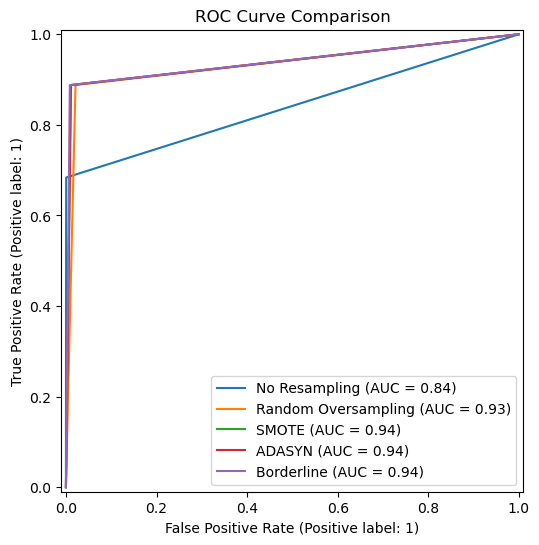

In [223]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

plt.figure(figsize=(6, 6))
for name, preds in methods.items():
    RocCurveDisplay.from_predictions(y_test, preds, name=name, ax=plt.gca())
plt.title("ROC Curve Comparison")
plt.show()


### 6.3 Confusion Matrices

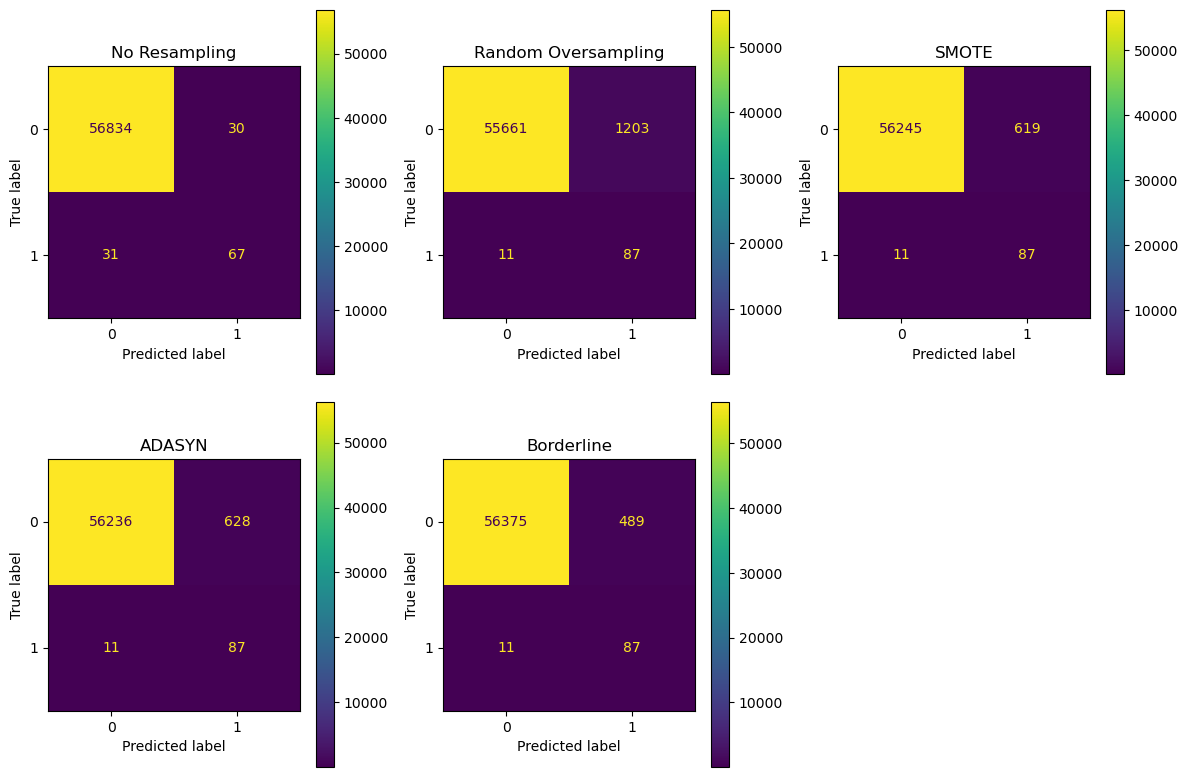

In [235]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

for ax, (name, preds) in zip(axes, list(methods.items())[:5]):
    ConfusionMatrixDisplay.from_predictions(y_test, preds, ax=ax)
    ax.set_title(name)

for ax in axes[5:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

### 6.4 Visuals for the README.me

In [240]:
for name, preds in methods.items():
    disp = ConfusionMatrixDisplay.from_predictions(y_test, preds)
    disp.ax_.set_title(f"{name} Confusion Matrix")
    
    # save PNG
    filename = f"{name.lower().replace(' ', '_')}_confusion_matrix.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.close()

---

## 7. Conclusion & Outlook

**On the low precision values**

Across all oversampling methods, the precision values turned out to be relatively low. This is typical behavior in fraud detection datasets: oversampling techniques (e.g. SMOTE, ADASYN, or ROS) generate additional minority samples. These synthetic points often lie close to the majority class, which leads the model to produce more **false positives**.  

**Typical trade-off: higher recall <--> lower precision.**

Oversampling increases **recall** (more fraud cases are detected) but decreases **precision** (more legitimate cases are misclassified as fraud). In real-world fraud detection, this trade-off is common: for many companies, a false positive (e.g. unnecessarily blocking a card) is less critical than a missed fraud case (fraud negative).

**My choice would be Borderline-SMOTE, since in all models (ROS, SMOTE, ADASYN, Borderline) I have 11 False Negatives and 87 True Positives, but Borderline has the lowest number of False Positives. ROS comes second, because although I have more True Negatives, it produces about three times as many False Positives.**

---

## 8. Next Steps
To improve precision, possible next steps include:

- **Threshold tuning** (adjusting the decision threshold).  
- **Cost-sensitive learning**, to reflect different error costs.  
- **Ensemble methods** or **anomaly detection approaches**, to create more robust models.
- Tune **hyperparameters** of oversampling methods  
- Explore **feature engineering** for better separation  

This experiment demonstrates that there is no one-size-fits-all solution: real-world fraud detection always requires balancing different performance metrics depending on business priorities.  


---